# 🎾 Khám Phá, Trực Quan Hóa & Tiền Xử Lý Dữ Liệu Bóng Tennis (Tennis Ball Dataset Preprocessing)

Notebook này thực hiện trực quan hóa toàn bộ quy trình tiền xử lý dữ liệu phát hiện bóng tennis cho mô hình YOLO26:
1. **Khám phá và phân tích cấu trúc** của 3 bộ dữ liệu ban đầu từ Roboflow (`dataset_1`, `dataset_2`, `dataset_3`).
2. **Trực quan hóa ảnh mẫu thô** kèm nhãn bounding box quả bóng.
3. **Quy trình hợp nhất dữ liệu (Dataset Merging)**: Khử xung đột tên file (`ds{idx}_`), thống nhất `class 0: tennis_ball`, tạo file cấu hình `data.yaml`.
4. **Trực quan hóa các bước tiền xử lý của YOLO**:
   - Thuật toán **Letterbox Resizing ($640 \times 640$)** bảo toàn hình học tròn của bóng vs Resize bóp méo hình.
   - Chuẩn hóa Bounding Box $[0, 1]$.
   - Mô phỏng tăng cường dữ liệu **Mosaic Augmentation (ghép 4 góc)** và **HSV Color Jitter**.

## 1. Thiết Lập Môi Trường & Thư Viện Cần Thiết

In [1]:
import os
import sys
import glob
import cv2
import yaml
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "temp" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("📁 Thư mục dự án:", project_root)
print("🐍 OpenCV version:", cv2.__version__)
print("📊 NumPy version:", np.__version__)

📁 Thư mục dự án: D:\FPT\DAT301m\tennis_analysis-main
🐍 OpenCV version: 5.0.0
📊 NumPy version: 2.1.3


## 2. Khám Phá & So Sánh Cấu Trúc 3 Bộ Dữ Liệu Gốc (Roboflow Datasets)
Phân tích chi tiết số lượng ảnh và file nhãn trong các tập `train`, `valid`, `test` của cả 3 dataset nguồn:
- **Dataset 1**: `viren-dhanwani/tennis-ball-detection`
- **Dataset 2**: `tennis-project-apdxz/ball-detection-pxnuq`
- **Dataset 3**: `me-dxtf3/tennis-ball-tracking-detection-h9rat`

In [2]:
ball_dir = os.path.join(project_root, "training/datasets/ball")

datasets_info = {
    "Dataset 1 (Viren Dhanwani)": os.path.join(ball_dir, "dataset_1_tennis_ball"),
    "Dataset 2 (Tennis Project)": os.path.join(ball_dir, "dataset_2_ball_detection"),
    "Dataset 3 (Me Tennis)": os.path.join(ball_dir, "dataset_3_me_tennis")
}

summary_rows = []

for ds_name, ds_path in datasets_info.items():
    if not os.path.exists(ds_path):
        continue
    for split in ["train", "valid", "test"]:
        img_dir = os.path.join(ds_path, split, "images")
        lbl_dir = os.path.join(ds_path, split, "labels")
        
        n_imgs = len(glob.glob(os.path.join(img_dir, "*.*"))) if os.path.exists(img_dir) else 0
        n_lbls = len(glob.glob(os.path.join(lbl_dir, "*.txt"))) if os.path.exists(lbl_dir) else 0
        
        total_boxes = 0
        if os.path.exists(lbl_dir):
            for lf in glob.glob(os.path.join(lbl_dir, "*.txt")):
                with open(lf, 'r') as f:
                    total_boxes += len(f.readlines())
                    
        summary_rows.append({
            "Dataset": ds_name,
            "Split": split,
            "Số ảnh": n_imgs,
            "Số file nhãn": n_lbls,
            "Tổng số BBox bóng": total_boxes
        })

df_summary = pd.DataFrame(summary_rows)
print("📊 BẢNG TỔNG HỢP CẤU TRÚC 3 BỘ DỮ LIỆU BÓNG BAN ĐẦU:")
print(df_summary.to_string(index=False))

📊 BẢNG TỔNG HỢP CẤU TRÚC 3 BỘ DỮ LIỆU BÓNG BAN ĐẦU:
                   Dataset Split  Số ảnh  Số file nhãn  Tổng số BBox bóng
Dataset 1 (Viren Dhanwani) train     428           428                426
Dataset 1 (Viren Dhanwani) valid     100           100                101
Dataset 1 (Viren Dhanwani)  test      50            50                 50
Dataset 2 (Tennis Project) train    2103          2103               2097
Dataset 2 (Tennis Project) valid     176           176                176
Dataset 2 (Tennis Project)  test      97            97                 97
     Dataset 3 (Me Tennis) train    1200          1200               1178
     Dataset 3 (Me Tennis) valid     150           150                147
     Dataset 3 (Me Tennis)  test     150           150                148


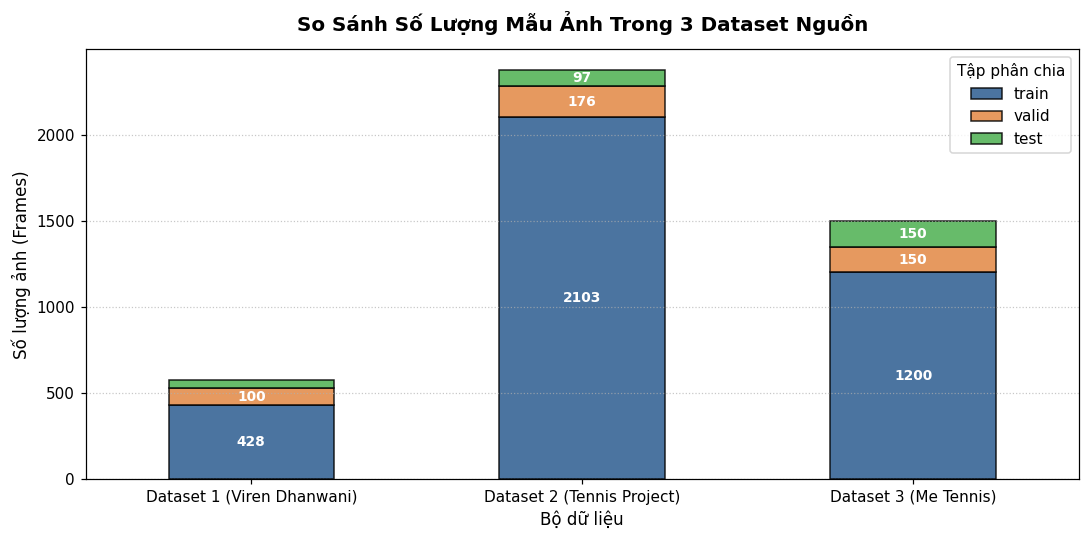

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot_df = df_summary.pivot(index="Dataset", columns="Split", values="Số ảnh")[["train", "valid", "test"]]

colors = ["#2b5c8f", "#e28743", "#4caf50"]
pivot_df.plot(kind="bar", stacked=True, ax=ax, color=colors, edgecolor="black", alpha=0.85)

ax.set_title("So Sánh Số Lượng Mẫu Ảnh Trong 3 Dataset Nguồn", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Số lượng ảnh (Frames)", fontsize=11)
ax.set_xlabel("Bộ dữ liệu", fontsize=11)
ax.grid(axis="y", linestyle=":", alpha=0.7)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title="Tập phân chia", fontsize=10)

for p in ax.patches:
    h = p.get_height()
    if h > 50:
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., p.get_y() + h / 2.),
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Trực Quan Hóa Mẫu Dữ Liệu Thô (Displaying Raw Samples & Bounding Boxes)
Trích xuất ngẫu nhiên các ảnh từ 3 bộ dữ liệu gốc và vẽ bounding box tọa độ bóng tennis (chuẩn hóa YOLO `[class, xc, yc, w, h]` sang tọa độ pixel `[x1, y1, x2, y2]`).

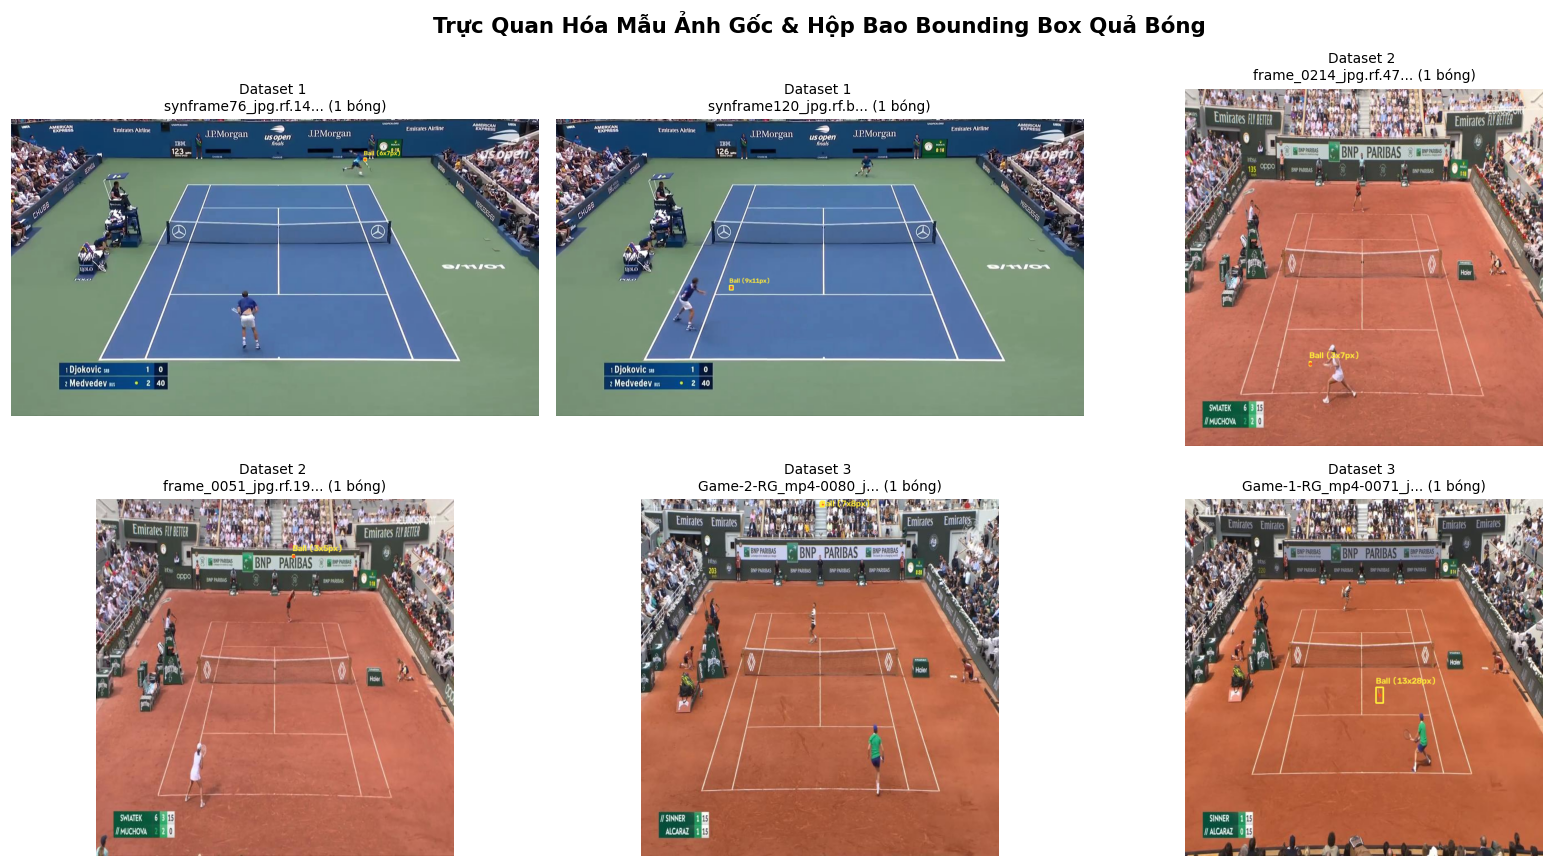

In [4]:
def draw_yolo_boxes(img_path, lbl_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = int((xc - bw / 2.0) * w)
                    y1 = int((yc - bh / 2.0) * h)
                    x2 = int((xc + bw / 2.0) * w)
                    y2 = int((yc + bh / 2.0) * h)
                    boxes.append((x1, y1, x2, y2))
                    
                    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 235, 59), 2)
                    cv2.circle(img_rgb, (int(xc * w), int(yc * h)), 3, (255, 87, 34), -1)
                    cv2.putText(img_rgb, f"Ball ({x2-x1}x{y2-y1}px)", (x1, max(15, y1 - 6)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 235, 59), 2)
    return img_rgb, boxes

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sample_idx = 0
for ds_name, ds_path in datasets_info.items():
    train_imgs = os.path.join(ds_path, "train", "images")
    train_lbls = os.path.join(ds_path, "train", "labels")
    if not os.path.exists(train_imgs):
        continue
    
    files = glob.glob(os.path.join(train_imgs, "*.*"))
    count = 0
    random.seed(42)
    for f_img in random.sample(files, min(len(files), 100)):
        stem = os.path.splitext(os.path.basename(f_img))[0]
        f_lbl = os.path.join(train_lbls, stem + ".txt")
        if os.path.exists(f_lbl) and os.path.getsize(f_lbl) > 0:
            res = draw_yolo_boxes(f_img, f_lbl)
            if res is not None:
                img_vis, bboxes = res
                ax = axes[sample_idx]
                ax.imshow(img_vis)
                ax.set_title(ds_name.split('(')[0] + "\n" + os.path.basename(f_img)[:20] + f"... ({len(bboxes)} bóng)", fontsize=9)
                ax.axis('off')
                sample_idx += 1
                count += 1
                if count >= 2 or sample_idx >= 6:
                    break

plt.suptitle("Trực Quan Hóa Mẫu Ảnh Gốc & Hộp Bao Bounding Box Quả Bóng", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## 4. Quá Trình Hợp Nhất Dữ Liệu (Dataset Merging & Label Unification)
Để huấn luyện mô hình YOLO26 đạt độ chính xác tối ưu, cả 3 dataset được gộp vào bộ duy nhất:
[`training/datasets/ball/merged_tennis_dataset`](training/datasets/ball/merged_tennis_dataset):
- **Khử xung đột tên ảnh:** Tự động gắn tiền tố `ds{idx}_` (ví dụ `ds0_frame_01.jpg`, `ds1_frame_01.jpg`).
- **Thống nhất lớp đối tượng:** Ép tất cả các class ID về `class 0: tennis_ball`.
- **Tạo file cấu hình chuẩn:** `data.yaml`.

In [5]:
merged_path = os.path.join(ball_dir, "merged_tennis_dataset")
yaml_path = os.path.join(merged_path, "data.yaml")

print("📁 Thư mục bộ gộp chuẩn:", merged_path)
print("📄 File cấu hình:", yaml_path)

if os.path.exists(yaml_path):
    with open(yaml_path, 'r', encoding='utf-8') as f:
        data_cfg = yaml.safe_load(f)
    print("\n✅ Cấu hình data.yaml:")
    print(" - Path:", data_cfg.get('path'))
    print(" - Train:", data_cfg.get('train'))
    print(" - Val:", data_cfg.get('val'))
    print(" - Test:", data_cfg.get('test'))
    print(" - Classes:", data_cfg.get('names'))

merged_stats = []
total_imgs = 0
total_lbls = 0

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(merged_path, split, "images")
    lbl_dir = os.path.join(merged_path, split, "labels")
    n_i = len(glob.glob(os.path.join(img_dir, "*.*"))) if os.path.exists(img_dir) else 0
    n_l = len(glob.glob(os.path.join(lbl_dir, "*.txt"))) if os.path.exists(lbl_dir) else 0
    total_imgs += n_i
    total_lbls += n_l
    merged_stats.append({"Split": split.upper(), "Số ảnh (Images)": n_i, "Số file nhãn (Labels)": n_l})

merged_stats.append({"Split": "TỔNG CỘNG", "Số ảnh (Images)": total_imgs, "Số file nhãn (Labels)": total_lbls})
df_merged = pd.DataFrame(merged_stats)
print("\n📊 THỐNG KÊ CHI TIẾT BỘ GỘP CHUẨN (MERGED TENNIS DATASET):")
print(df_merged.to_string(index=False))

📁 Thư mục bộ gộp chuẩn: D:\FPT\DAT301m\tennis_analysis-main\training/datasets/ball\merged_tennis_dataset
📄 File cấu hình: D:\FPT\DAT301m\tennis_analysis-main\training/datasets/ball\merged_tennis_dataset\data.yaml

✅ Cấu hình data.yaml:
 - Path: D:\FPT\DAT301m\tennis_analysis-main\training\datasets\ball\merged_tennis_dataset
 - Train: train/images
 - Val: valid/images
 - Test: test/images
 - Classes: {0: 'tennis_ball'}

📊 THỐNG KÊ CHI TIẾT BỘ GỘP CHUẨN (MERGED TENNIS DATASET):
    Split  Số ảnh (Images)  Số file nhãn (Labels)
    TRAIN             3731                   3731
    VALID              426                    426
     TEST              297                    297
TỔNG CỘNG             4454                   4454


## 5. Trực Quan Hóa Thuật Toán Letterbox Resizing ($640 \times 640$)
So sánh trực quan:
- **Ảnh gốc (1280x720):** Khung hình chữ nhật tỷ lệ 16:9.
- **Resize kéo méo thông thường (Distorted Resize):** Quả bóng bị bóp dẹt thành hình elip, sai lệch tỷ lệ vật lý.
- **Letterbox Resize (YOLO26):** Giữ tỷ lệ khung hình chuẩn $1:1$, bù viền đệm màu xám giá trị `114` $\to$ Quả bóng giữ trọn hình tròn đối xứng.

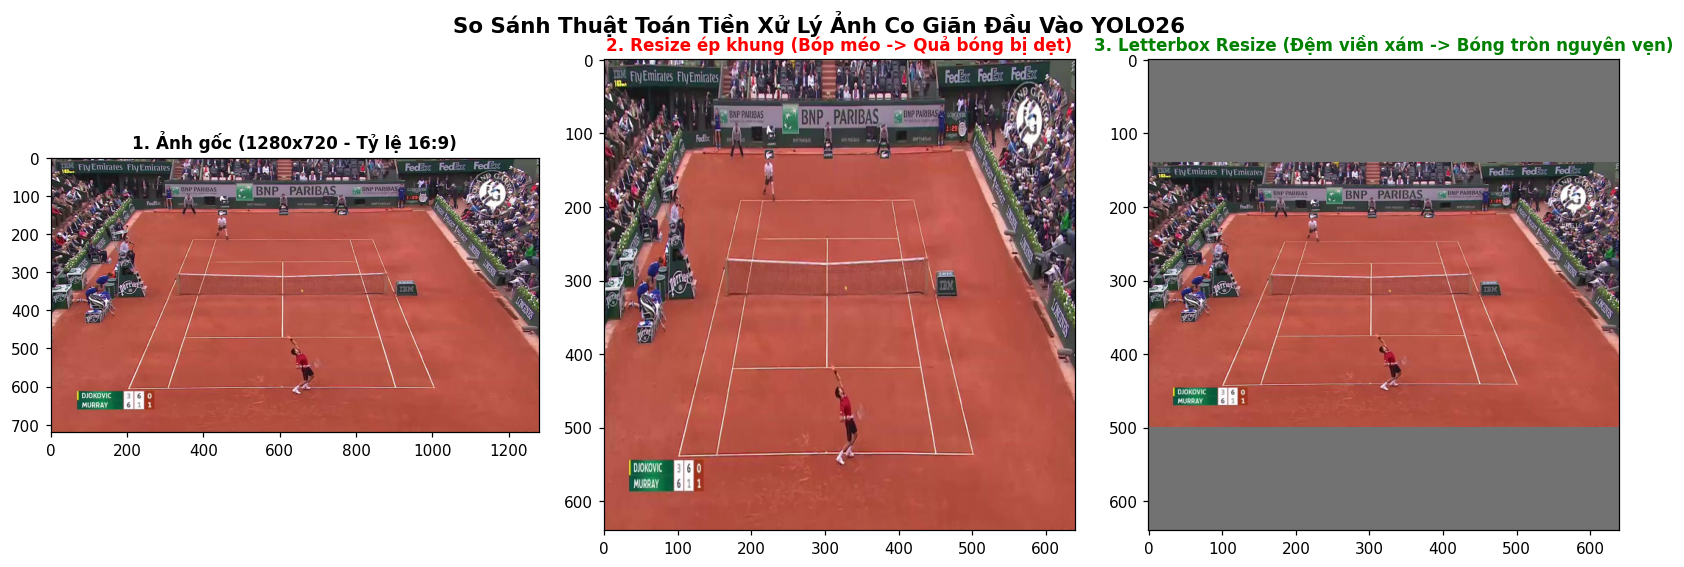

In [6]:
def letterbox_image(image, target_size=(640, 640), pad_color=(114, 114, 114)):
    ih, iw = image.shape[:2]
    tw, th = target_size
    scale = min(tw / iw, th / ih)
    nw, nh = int(iw * scale), int(ih * scale)
    
    resized = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
    letterboxed = np.full((th, tw, 3), pad_color, dtype=np.uint8)
    
    dx = (tw - nw) // 2
    dy = (th - nh) // 2
    letterboxed[dy:dy+nh, dx:dx+nw] = resized
    return letterboxed, scale, dx, dy

merged_train_imgs = glob.glob(os.path.join(merged_path, "train/images/*.*"))
sample_img_p = merged_train_imgs[0]
raw_sample = cv2.imread(sample_img_p)
raw_rgb = cv2.cvtColor(raw_sample, cv2.COLOR_BGR2RGB)

distorted = cv2.resize(raw_rgb, (640, 640))
letterboxed, scale, dx, dy = letterbox_image(raw_rgb, (640, 640))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_rgb)
axes[0].set_title(f"1. Ảnh gốc ({raw_rgb.shape[1]}x{raw_rgb.shape[0]} - Tỷ lệ 16:9)", fontsize=11, fontweight="bold")
axes[0].axis('on')

axes[1].imshow(distorted)
axes[1].set_title("2. Resize ép khung (Bóp méo -> Quả bóng bị dẹt)", fontsize=11, color="red", fontweight="bold")
axes[1].axis('on')

axes[2].imshow(letterboxed)
axes[2].set_title("3. Letterbox Resize (Đệm viền xám -> Bóng tròn nguyên vẹn)", fontsize=11, color="green", fontweight="bold")
axes[2].axis('on')

plt.suptitle("So Sánh Thuật Toán Tiền Xử Lý Ảnh Co Giãn Đầu Vào YOLO26", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Mô Phỏng Kỹ Thuật Tăng Cường Dữ Liệu (Data Augmentation Simulation)
YOLO26 tự động áp dụng các phép tăng cường dữ liệu đặc thù để phát hiện quả bóng siêu nhỏ:
- **Mosaic Augmentation:** Ghép 4 ảnh ngẫu nhiên giúp mô hình học phát hiện bóng ở cự ly xa và bối cảnh phức tạp.
- **HSV Color Jitter:** Thay đổi sắc độ màu, độ bão hòa và độ sáng giúp nhận diện quả bóng vàng dưới mọi điều kiện ánh sáng nắng gắt/bóng râm.

🎉 Hoàn tất toàn bộ quy trình trực quan hóa tiền xử lý dữ liệu bóng tennis!


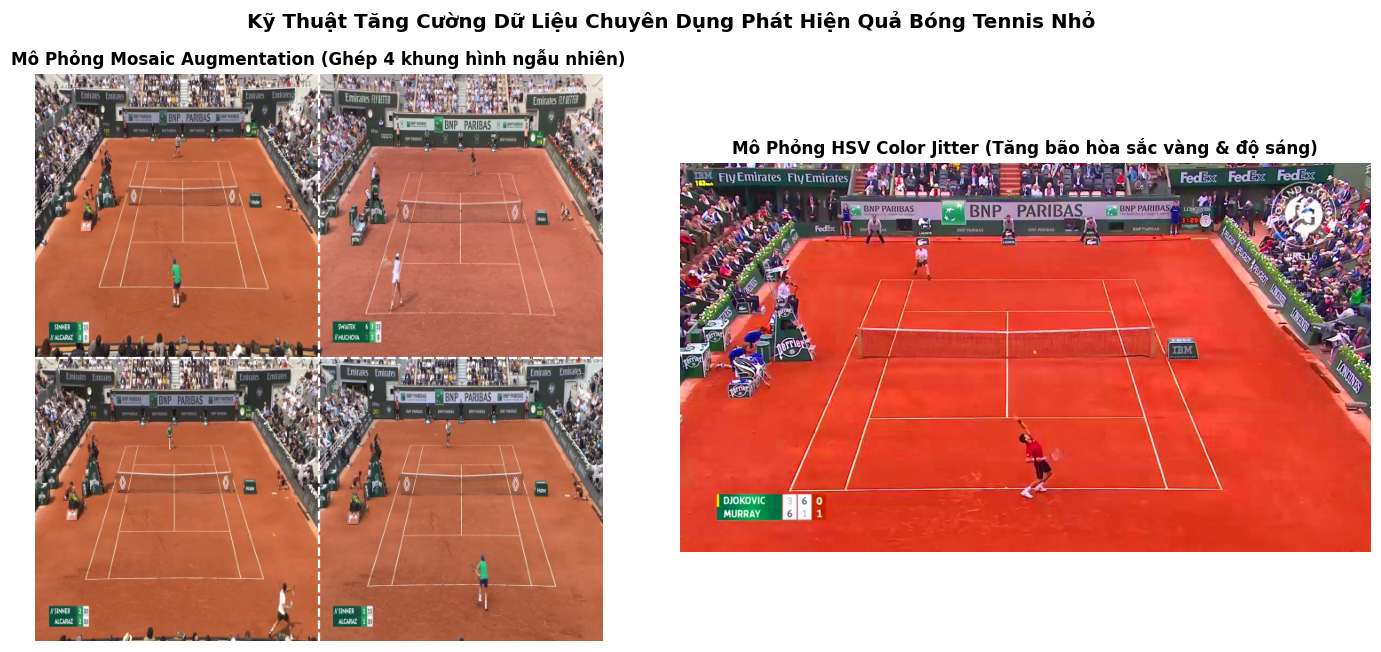

In [7]:
h, w = 640, 640
mosaic_img = np.full((h, w, 3), 114, dtype=np.uint8)
xc, yc = int(w * 0.5), int(h * 0.5)

selected_samples = random.sample(merged_train_imgs, 4)

img1 = cv2.cvtColor(cv2.imread(selected_samples[0]), cv2.COLOR_BGR2RGB)
mosaic_img[:yc, :xc] = cv2.resize(img1, (xc, yc))

img2 = cv2.cvtColor(cv2.imread(selected_samples[1]), cv2.COLOR_BGR2RGB)
mosaic_img[:yc, xc:] = cv2.resize(img2, (w - xc, yc))

img3 = cv2.cvtColor(cv2.imread(selected_samples[2]), cv2.COLOR_BGR2RGB)
mosaic_img[yc:, :xc] = cv2.resize(img3, (xc, h - yc))

img4 = cv2.cvtColor(cv2.imread(selected_samples[3]), cv2.COLOR_BGR2RGB)
mosaic_img[yc:, xc:] = cv2.resize(img4, (w - xc, h - yc))

hsv = cv2.cvtColor(raw_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.35, 0, 255)
hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.25, 0, 255)
bright_rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(mosaic_img)
axes[0].axvline(x=xc, color="white", linestyle="--", linewidth=1.5)
axes[0].axhline(y=yc, color="white", linestyle="--", linewidth=1.5)
axes[0].set_title("Mô Phỏng Mosaic Augmentation (Ghép 4 khung hình ngẫu nhiên)", fontsize=11, fontweight="bold")
axes[0].axis('off')

axes[1].imshow(bright_rgb)
axes[1].set_title("Mô Phỏng HSV Color Jitter (Tăng bão hòa sắc vàng & độ sáng)", fontsize=11, fontweight="bold")
axes[1].axis('off')

plt.suptitle("Kỹ Thuật Tăng Cường Dữ Liệu Chuyên Dụng Phát Hiện Quả Bóng Tennis Nhỏ", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("🎉 Hoàn tất toàn bộ quy trình trực quan hóa tiền xử lý dữ liệu bóng tennis!")